# scWAT Xenium QC Region2
## Xiaonan Wang
## 18Aug2026

## Setup

### Parameters

Change `REGION_ID` for manual execution. Launchers inject the same parameters without editing the source notebook.

In [1]:
PROJECT_ROOT <- "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium"
PIPELINE_REPO <- file.path(PROJECT_ROOT, "adipose_analysis", "YNH_Xenium_scWAT")
INPUT_ROOT <- file.path(PROJECT_ROOT, "adipose_data")
REGION_ID <- "Region_2"
RUN_LABEL <- "full_notebook_qc_v2"
METADATA_PATH <- file.path(PIPELINE_REPO, "config", "scwat_sample_manifest.tsv")
EXPECTED_SECTION_COUNT <- 4L
SEED <- 20260814L
STRICT_MODE <- FALSE
EXTENDED_QC_MODE <- "AUTO"
EXTENDED_QC_CONFIG_PATH <- file.path(PIPELINE_REPO, "config", "extended_qc_defaults.tsv")
FIXED_CELL_QC_THRESHOLDS_PATH <- file.path(PIPELINE_REPO, "config", "fixed_cell_qc_thresholds.tsv")


In [2]:
OUTPUT_ROOT <- file.path(PROJECT_ROOT, "adipose_analysis", "scwat_qc_outputs", RUN_LABEL)
SECTION_OUTPUT_DIR <- file.path(OUTPUT_ROOT, "sections", REGION_ID)

In [3]:
source(file.path(PIPELINE_REPO, "R", "source.R"))
fixed_thresholds <- read_fixed_cell_qc_thresholds(FIXED_CELL_QC_THRESHOLDS_PATH)


In [4]:
for (package in c("Matrix", "jsonlite", "ggplot2")) require_package(package)

In [5]:
dir.create(SECTION_OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)
stopifnot(REGION_ID %in% paste0("Region_", seq_len(EXPECTED_SECTION_COUNT)))
cat("Section:", REGION_ID, "\nOutput:", SECTION_OUTPUT_DIR, "\n")

Section: Region_2 
Output: /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2 


## Inputs

The selected raw/subset section directory is discovered by region ID. 

In [6]:
all_sections <- discover_xenium_sections(INPUT_ROOT, EXPECTED_SECTION_COUNT)

In [7]:
all_sections

region_id,region_number,region_dir
<chr>,<int>,<chr>
Region_1,1,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_1__20260805__124712
Region_2,2,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_2__20260805__124712
Region_3,3,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_3__20260805__124712
Region_4,4,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_4__20260805__124712


In [8]:
selected_section <- discover_one_section(INPUT_ROOT, REGION_ID)
selected_section

region_id,region_number,region_dir
<chr>,<int>,<chr>
Region_2,2,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_2__20260805__124712


## Step1 - Configuration and metadata contract

In [9]:
if (nzchar(METADATA_PATH)) {
  assert_path_within(PROJECT_ROOT, METADATA_PATH)
  full_manifest <- utils::read.delim(METADATA_PATH, check.names = FALSE)
} else {
  full_manifest <- create_synthetic_manifest(all_sections$region_id, SEED)
}

In [10]:
full_manifest

tissue,region_id,mouse_id,section_id,biological_replicate_id,technical_replicate_id,genotype,treatment,condition,age_weeks,metadata_status,do_not_interpret,notes
<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>
scWAT,Region_1,Mouse_1,62308,Mouse_1,Region_1,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62308; no left/right factor
scWAT,Region_2,Mouse_1,62309,Mouse_1,Region_2,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62309; no left/right factor
scWAT,Region_3,Mouse_2,62310,Mouse_2,Region_3,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62310; no left/right factor
scWAT,Region_4,Mouse_2,62311,Mouse_2,Region_4,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62311; no left/right factor


In [11]:
# manifest_check <- validate_sample_manifest(full_manifest, all_sections$region_id)
# if (!manifest_check$valid) stop(paste(manifest_check$issues, collapse = "; "))

In [12]:
section_manifest <- full_manifest[full_manifest$region_id == REGION_ID, , drop = FALSE]
section_manifest$region_dir <- selected_section$region_dir

In [13]:
section_manifest

,tissue,region_id,mouse_id,section_id,biological_replicate_id,technical_replicate_id,genotype,treatment,condition,age_weeks,metadata_status,do_not_interpret,notes,region_dir
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>,<chr>
2,scWAT,Region_2,Mouse_1,62309,Mouse_1,Region_2,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62309; no left/right factor,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_2__20260805__124712


In [14]:
configuration <- data.frame(
  key = c("project_root", "pipeline_repo", "input_root", "output_root", "region_id", "run_label", "seed", "strict_mode"),
  value = c(PROJECT_ROOT, PIPELINE_REPO, INPUT_ROOT, OUTPUT_ROOT, REGION_ID, RUN_LABEL, SEED, STRICT_MODE)
)

In [15]:
configuration

key,value
<chr>,<chr>
project_root,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium
pipeline_repo,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/YNH_Xenium_scWAT
input_root,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data
output_root,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
region_id,Region_2
run_label,full_notebook_qc_v2
seed,20260814
strict_mode,FALSE


In [16]:
environment <- data.frame(
  item = c("R_version", "platform", "tempdir", "Matrix", "jsonlite", "ggplot2"),
  value = c(R.version.string, R.version$platform, tempdir(), as.character(packageVersion("Matrix")), as.character(packageVersion("jsonlite")), as.character(packageVersion("ggplot2")))
)

In [17]:
environment

item,value
<chr>,<chr>
R_version,R version 4.5.3 (2026-03-11)
platform,x86_64-conda-linux-gnu
tempdir,/tmp/Rtmp32TsF3
Matrix,1.7.6
jsonlite,2.0.0
ggplot2,4.0.3


## Step2 - Provenance, integrity, panel reconciliation, and QC gate

In [18]:
region_dir <- selected_section$region_dir[[1]]
inventory <- inventory_section_files(region_dir, REGION_ID, calculate_md5 = TRUE)

In [19]:
inventory

region_id,relative_path,exists,size_bytes,modified_utc,md5
<chr>,<chr>,<lgl>,<dbl>,<chr>,<chr>
Region_2,experiment.xenium,TRUE,2776,2026-08-13 14:27:58 UTC,23bc946b10405ce0836adcbab6110d17
Region_2,metrics_summary.csv,TRUE,2200,2026-08-13 14:27:58 UTC,058debb020613f79ca787db2bdd247ea
Region_2,analysis_summary.html,TRUE,8546768,2026-08-13 14:26:51 UTC,e0f2a219b308f0981b40101c2a13ac5f
Region_2,gene_panel.json,TRUE,256874,2026-08-13 14:27:59 UTC,88b3b1dc6443d266a7419c2b129e31b7
Region_2,cells.csv.gz,TRUE,3961860,2026-08-13 14:26:52 UTC,b0f0faee3761cd140803ee385ac6b482
Region_2,cell_feature_matrix/features.tsv.gz,TRUE,4272,2026-08-13 15:23:10 UTC,d08756f5e8c127b8db091a2746943ca0
Region_2,cell_feature_matrix/barcodes.tsv.gz,TRUE,297988,2026-08-13 15:23:13 UTC,7e0dab8ed2468a7421a569af323facad
Region_2,cell_feature_matrix/matrix.mtx.gz,TRUE,17861838,2026-08-13 15:23:22 UTC,bbe0d4ec776e74adeac940f6f0ba31a4


In [20]:
# if (!all(inventory$exists)) stop(paste("Missing required files:", paste(inventory$relative_path[!inventory$exists], collapse = ", ")))

In [21]:
# check 
## matrix.mtx.gz
## features.tsv.gz
## barcodes.tsv.gz
## cells.csv.gz
integrity <- validate_section_integrity(region_dir, REGION_ID)

In [22]:
integrity

region_id,matrix_features,matrix_cells,matrix_nonzero,feature_rows,barcode_rows,cell_rows,duplicate_cell_ids,dimension_match
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>
Region_2,541,66980,3703838,541,66980,66980,0,TRUE


In [23]:
alarms <- extract_analysis_alarms(file.path(region_dir, "analysis_summary.html"))

In [24]:
alarms

,raw_value,formatted_value,raised,title,message,level,id
,<lgl>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>
1,TRUE,True,TRUE,Poor quality imaging cycles detected,"A significant fraction of transcripts were missing from one or more imaging cycles. This could be caused by improper sample handling, insufficient reagent loading, high sample auto-fluorescence, or due to an algorithmic failure. This error may impact the quality score of transcripts from one or more genes. Please contact 10x support (support@10xgenomics.com) for diagnostics and troubleshooting.",ERROR,poor_quality_cycles_detected


In [25]:
# Gene gene annotations - from yanan
signature <- utils::read.delim(file.path(PIPELINE_REPO, "config", "eos_gene_sets.tsv"), check.names = FALSE)
gene_sets <- setNames(signature$gene_set, signature$gene)

In [26]:
table(signature$gene_set)


     common  long_lived short_lived 
          7          46          47 

In [27]:
nrow(signature)

[1] 100

In [28]:
# from xenium output
installed_genes <- read_custom_panel_genes(file.path(region_dir, "gene_panel.json"))

In [29]:
length(installed_genes)

[1] 100

In [30]:
# check if all match
panel_reconciliation <- reconcile_panel(signature$gene, installed_genes, gene_sets)

In [31]:
table(panel_reconciliation$status)


MATCH 
  100 

In [32]:
features_preview <- read_xenium_features(file.path(region_dir, "cell_feature_matrix", "features.tsv.gz"))

In [33]:
head(features_preview)

,feature_id,feature_name,feature_type
,<chr>,<chr>,<chr>
1,ENSMUSG00000109644,0610005C13Rik,Gene Expression
2,ENSMUSG00000028441,1110017D15Rik,Gene Expression
3,ENSMUSG00000096001,2610528A11Rik,Gene Expression
4,ENSMUSG00000040412,5330417C22Rik,Gene Expression
5,ENSMUSG00000018451,6330403K07Rik,Gene Expression
6,ENSMUSG00000109321,A330076H08Rik,Gene Expression


In [34]:
dim(features_preview)

[1] 541   3

In [35]:
feature_type_summary <- as.data.frame(table(features_preview$feature_type), stringsAsFactors = FALSE)
names(feature_type_summary) <- c("feature_type", "n_features")

In [36]:
feature_type_summary

feature_type,n_features
<chr>,<int>
Gene Expression,479
Negative Control Codeword,41
Negative Control Probe,20
Unassigned Codeword,1


## Step3 - Sparse import and section-specific cell QC

In [37]:
# read in 
## features.tsv.gz
## barcodes.tsv.gz
## matrix.mtx.gz
## cells.csv.gz
xenium <- import_xenium_mex(region_dir)

In [38]:
head(xenium$cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<chr>
aaaaanii-1,aaaaanii-1,2125.366,2918.076,79,0,0,0,0,0,79,58.02578,25.10688,1,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin)
aaaaofbk-1,aaaaofbk-1,2130.218,2957.009,62,0,0,0,0,0,62,134.47532,27.27438,2,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin)


In [39]:
table(xenium$cells$segmentation_method)


Segmented by boundary stain (ATP1A1+CD45+E-Cadherin) 
                                               16221 
                   Segmented by interior stain (18S) 
                                               49622 
             Segmented by nucleus expansion of 5.0µm 
                                                1137 

In [40]:
table(xenium$cells$nucleus_count)


    0     1     2     3     4     5 
  908 65180   839    43     9     1 

In [41]:
xenium$raw_matrix_dimensions

features    cells  nonzero 
     541    66980  3703838

In [42]:
xenium$raw_matrix_dimensions[3]*100/(xenium$raw_matrix_dimensions[1]*xenium$raw_matrix_dimensions[2])

nonzero 
10.22138

### Prespecified core cell-QC rule

A cell passes `qc_core_pass` only when both strict open intervals hold:

- `5 < nFeature_Xenium < 200`
- `10 < nCount_Xenium < 1000`

Values exactly equal to 5, 200, 10, or 1000 fail. Robust distribution limits remain diagnostic only and do not redefine this cohort.


In [43]:
qc <- calculate_xenium_cell_qc(
  xenium$counts, xenium$cells, REGION_ID,
  fixed_thresholds = fixed_thresholds
)
metadata_columns <- intersect(c("mouse_id", "side", "section_id", "biological_replicate_id", "genotype", "treatment", "condition", "age_weeks", "metadata_status", "do_not_interpret"), names(section_manifest))
for (column in metadata_columns) qc$cell_metadata[[column]] <- section_manifest[[column]][[1]]

In [44]:
qc$thresholds

,region_id,metric,lower,upper,value,method
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
method,Region_2,nCount_Xenium,1,625.6710,129.00000,median_minus_3MAD_plus_5MAD
method1,Region_2,nFeature_Xenium,1,187.4340,54.00000,median_minus_3MAD_plus_5MAD
method2,Region_2,cell_area,0,257.7498,63.26391,median_minus_5MAD_plus_5MAD
1,Region_2,control_fraction_cell,0,0.0500,0.00000,max_5pct_or_q99.5


In [45]:
head(qc$cell_metadata, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,qc_review_flag,mouse_id,section_id,biological_replicate_id,genotype,treatment,condition,age_weeks,metadata_status,do_not_interpret
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<lgl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>
aaaaanii-1,aaaaanii-1,2125.366,2918.076,79,0,0,0,0,0,79,⋯,FALSE,Mouse_1,62309,Mouse_1,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE
aaaaofbk-1,aaaaofbk-1,2130.218,2957.009,62,0,0,0,0,0,62,⋯,TRUE,Mouse_1,62309,Mouse_1,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE


In [46]:
qc$summary

region_id,input_cells,core_qc_pass,core_qc_fail,review_flagged,nucleus_missing,multiple_nuclei,segmentation_multiplet,area_outlier,high_control,cells_deleted
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Region_2,66980,66567,413,2703,908,892,952,640,18,0


In [47]:
section_plots <- plot_section_qc(qc$cell_metadata, REGION_ID)

In [48]:
options(repr.plot.width=6, repr.plot.height=4)

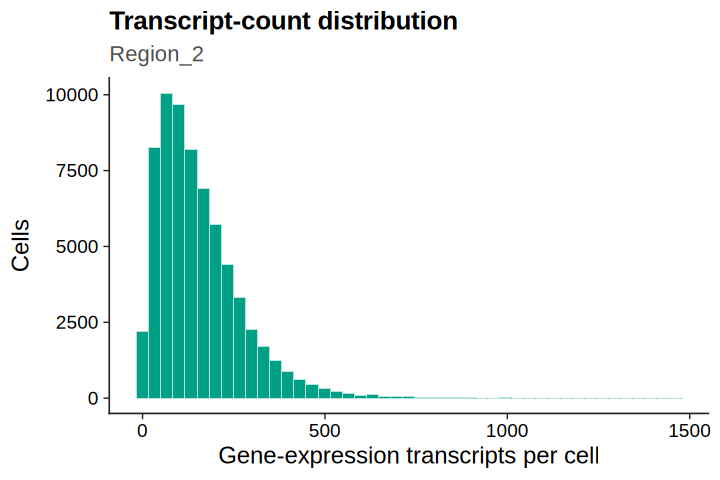

In [49]:
print(section_plots$counts)

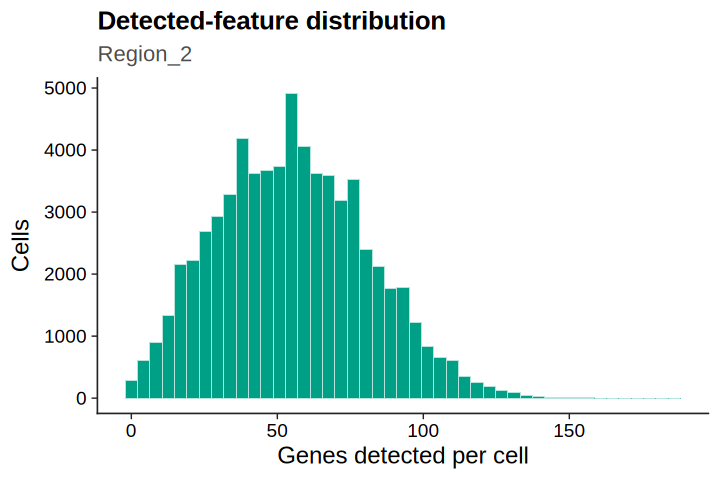

In [50]:
print(section_plots$features)

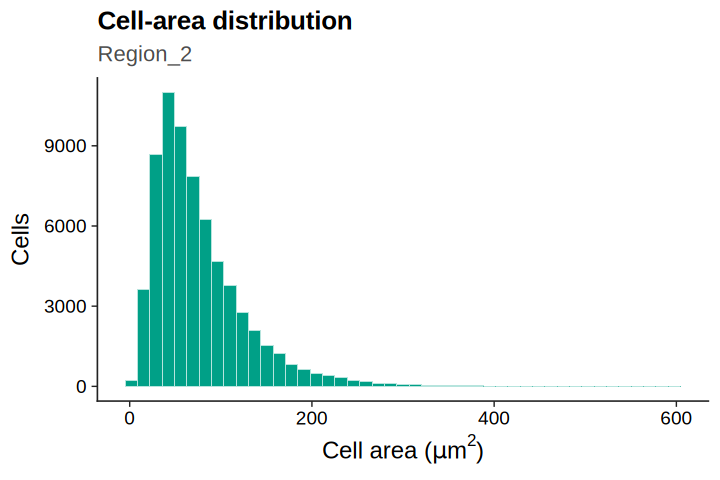

In [51]:
print(section_plots$area)

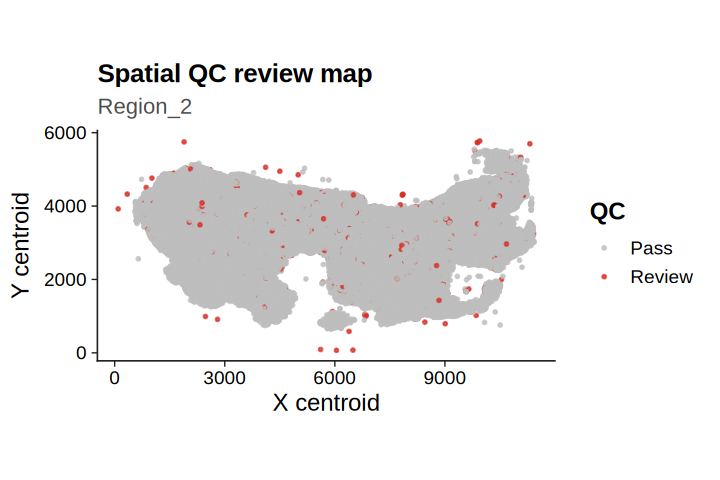

In [52]:
print(section_plots$spatial)

## Step4 - Cycle Alarm Check

In [53]:
extended_config <- read_extended_qc_config(EXTENDED_QC_CONFIG_PATH)

In [54]:
t(as.data.frame(extended_config))

qv_threshold,20.00
spatial_k,15.00
grid_size_um,100.00
permutations,999.00
dense_quantile,0.90
min_bin_cells,20.00
hotspot_fdr,0.05
candidate_abs_log2_ratio,0.50
candidate_abs_q20_delta,0.05
concordance_gene_spearman,0.90
concordance_review_rate_difference,0.05


In [55]:
extended_mode <- resolve_extended_qc_mode(EXTENDED_QC_MODE, region_dir)

In [56]:
extended_mode

[1] "FULL_HPC"

In [57]:
# check package availability
extended_preflight <- extended_qc_preflight(extended_mode, region_dir, extended_config)

In [58]:
extended_preflight

check,required,available,status,details,mode
<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>
transcripts_parquet,TRUE,TRUE,PASS,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_2__20260805__124712/transcripts.parquet,FULL_HPC
arrow,TRUE,TRUE,PASS,R package for projected Parquet aggregation,FULL_HPC
dplyr,TRUE,TRUE,PASS,R package for lazy Arrow grouping and aggregation,FULL_HPC
RANN,TRUE,TRUE,PASS,R package for scalable nearest-neighbour calculations,FULL_HPC


In [59]:
# if (extended_mode == "FULL_HPC" && any(extended_preflight$status == "FAIL")) {
#   stop(paste("FULL_HPC extended preflight failed:", paste(extended_preflight$check[extended_preflight$status == "FAIL"], collapse = ", ")))
# }

In [60]:
cycle_alarm_evidence <- build_cycle_alarm_evidence(alarms, REGION_ID)

In [61]:
cycle_alarm_evidence

,region_id,raised,title,message,level,id,evidence_status,cycle_identity_status,gene_effect_status
,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Region_2,TRUE,Poor quality imaging cycles detected,"A significant fraction of transcripts were missing from one or more imaging cycles. This could be caused by improper sample handling, insufficient reagent loading, high sample auto-fluorescence, or due to an algorithmic failure. This error may impact the quality score of transcripts from one or more genes. Please contact 10x support (support@10xgenomics.com) for diagnostics and troubleshooting.",ERROR,poor_quality_cycles_detected,DIRECT_EVIDENCE,CYCLE_IDENTITY_UNRESOLVED_REQUIRES_10X,GENE_EFFECT_UNCONFIRMED


In [62]:
cat("Extended mode:", extended_mode, "\nInput:", region_dir, "\nOutput:", SECTION_OUTPUT_DIR, "\n")

Extended mode: FULL_HPC 
Input: /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_2__20260805__124712 
Output: /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2 


## Step5 - Per-gene quality diagnostics

In [63]:
matrix_gene_quality <- summarise_gene_matrix_qc(xenium$counts, REGION_ID, gene_sets)

In [64]:
head(matrix_gene_quality,n=2)

,region_id,gene,gene_set,raw_counts,counts_per_10000,detected_cells,detection_fraction,matrix_cells
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,Region_2,0610005C13Rik,NA,2228,2.147613,2159,0.03223350,66980
2,Region_2,1110017D15Rik,NA,957,0.922471,927,0.01383995,66980


In [65]:
extended_config$qv_threshold

[1] 20

In [66]:
transcript_gene_quality <- data.frame()
# qv: qualiity value
# q20: qv >= qv_threshold, which = 20
if (extended_mode == "FULL_HPC") {
  transcript_gene_quality <- summarise_transcript_quality_arrow(file.path(region_dir, "transcripts.parquet"), REGION_ID, extended_config$qv_threshold)
  gene_quality <- combine_gene_quality(matrix_gene_quality, transcript_gene_quality)
} else {
  gene_quality <- matrix_gene_quality
  gene_quality$transcript_rows <- NA_integer_
  gene_quality$mean_qv <- NA_real_
  gene_quality$fraction_q20 <- NA_real_
  gene_quality$represented_codewords <- NA_integer_
  gene_quality$transcript_status <- "NOT_RUN_LOCAL_SUBSET"
}

In [67]:
head(transcript_gene_quality, n =2)

,region_id,gene,transcript_rows,mean_qv,fraction_q20,represented_codewords,transcript_status
,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<chr>
140,Region_2,0610005C13Rik,3423,27.30470,0.6868244,1,MEASURED_ARROW_PROJECTED_AGGREGATE
513,Region_2,1110017D15Rik,1557,27.17534,0.6525369,1,MEASURED_ARROW_PROJECTED_AGGREGATE


In [68]:
head(gene_quality, n = 2)

,region_id,gene,gene_set,raw_counts,counts_per_10000,detected_cells,detection_fraction,matrix_cells,transcript_rows,mean_qv,fraction_q20,represented_codewords,transcript_status
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<chr>
1,Region_2,0610005C13Rik,NA,2228,2.147613,2159,0.03223350,66980,3423,27.30470,0.6868244,1,MEASURED_ARROW_PROJECTED_AGGREGATE
2,Region_2,1110017D15Rik,NA,957,0.922471,927,0.01383995,66980,1557,27.17534,0.6525369,1,MEASURED_ARROW_PROJECTED_AGGREGATE


## Step6 - Spatial diagnostics

In [69]:
extended_config$grid_size_um

[1] 100

In [70]:
spatial_cells <- assign_spatial_grid(qc$cell_metadata, extended_config$grid_size_um)

In [71]:
dim(spatial_cells)

[1] 66980    39

In [72]:
head(spatial_cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,treatment,condition,age_weeks,metadata_status,do_not_interpret,grid_x,grid_y,grid_id,edge_proxy,grid_size_um
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<int>,<chr>,<lgl>,<int>,<int>,<chr>,<lgl>,<dbl>
aaaaanii-1,aaaaanii-1,2125.366,2918.076,79,0,0,0,0,0,79,⋯,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,20,28,20:28,FALSE,100
aaaaofbk-1,aaaaofbk-1,2130.218,2957.009,62,0,0,0,0,0,62,⋯,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,20,28,20:28,FALSE,100


In [73]:
spatial_k <- min(as.integer(extended_config$spatial_k), nrow(spatial_cells) - 1L)

In [74]:
spatial_k

[1] 15

In [75]:
spatial_cells$local_density <- calculate_knn_density(spatial_cells, spatial_k, extended_mode)

In [76]:
head(spatial_cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,condition,age_weeks,metadata_status,do_not_interpret,grid_x,grid_y,grid_id,edge_proxy,grid_size_um,local_density
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<int>,<chr>,<lgl>,<int>,<int>,<chr>,<lgl>,<dbl>,<dbl>
aaaaanii-1,aaaaanii-1,2125.366,2918.076,79,0,0,0,0,0,79,⋯,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,20,28,20:28,FALSE,100,0.003101820
aaaaofbk-1,aaaaofbk-1,2130.218,2957.009,62,0,0,0,0,0,62,⋯,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,20,28,20:28,FALSE,100,0.004515598


In [77]:
extended_config$dense_quantile

[1] 0.9

In [78]:
density_cutoff <- stats::quantile(spatial_cells$local_density, extended_config$dense_quantile, na.rm = TRUE)
spatial_cells$dense_aggregate <- spatial_cells$local_density >= density_cutoff

In [79]:
table(spatial_cells$dense_aggregate)


FALSE  TRUE 
60282  6698 

In [80]:
head(spatial_cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,age_weeks,metadata_status,do_not_interpret,grid_x,grid_y,grid_id,edge_proxy,grid_size_um,local_density,dense_aggregate
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<lgl>,<int>,<int>,<chr>,<lgl>,<dbl>,<dbl>,<lgl>
aaaaanii-1,aaaaanii-1,2125.366,2918.076,79,0,0,0,0,0,79,⋯,8,VERIFIED_USER_SUPPLIED,FALSE,20,28,20:28,FALSE,100,0.003101820,FALSE
aaaaofbk-1,aaaaofbk-1,2130.218,2957.009,62,0,0,0,0,0,62,⋯,8,VERIFIED_USER_SUPPLIED,FALSE,20,28,20:28,FALSE,100,0.004515598,FALSE


In [81]:
# if QC flags cluster together?
spatial_global <- test_spatial_flag_clustering(spatial_cells, spatial_k, extended_config$permutations, extended_config$seed, extended_mode)
spatial_global$region_id <- REGION_ID

In [82]:
spatial_global

status,statistic,empirical_p,permutations,k,seed,region_id
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
ESTIMATED,0.02144443,0.001,999,15,20260814,Region_2


QC-flagged cells in Region 2 are not randomly scattered, they are spatially clustered!

In [83]:
# check spatial enrichment
spatial_edge_density <- summarise_spatial_enrichment(spatial_cells)
spatial_edge_density$region_id <- REGION_ID

In [84]:
spatial_edge_density

class_type,class,cells,flagged,review_rate,risk_ratio,absolute_rate_difference,region_id
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
edge_proxy,edge,4272,227,0.05313670,1.3481557,0.01365211,Region_2
edge_proxy,interior,62708,2476,0.03948460,1.3481557,0.01365211,Region_2
local_density,dense,6698,127,0.01896088,0.4453125,-0.02377161,Region_2
local_density,non_dense,60282,2576,0.04273249,0.4453125,-0.02377161,Region_2


- cells near the tissue edge are about 34% more likely to be QC-flagged than interior cells -> a real edge effect, but the absolute increase is modest
- dense regions are protective with respect to QC flags, the flag rate is about 56% lower in dense areas than in non-dense areas

Thus, Region 2 QC flags are spatially non-random, with some enrichment near tissue edges, but they are not driven by dense cellular regions. The effect size is modest overall.

In [85]:
# find spatial hotspots
spatial_hotspots <- find_spatial_qc_hotspots(spatial_cells, extended_config$permutations, extended_config$min_bin_cells, extended_config$hotspot_fdr, extended_config$seed)
spatial_hotspots$region_id <- rep(REGION_ID, nrow(spatial_hotspots))

In [86]:
dim(spatial_hotspots)

[1] 1208   18

In [87]:
head(spatial_hotspots,n=2)

,grid_id,cells,flagged,review_rate,global_rate,rate_difference,empirical_p,adjusted_p,hotspot_status,x_min,x_max,y_min,y_max,fdr_threshold,min_bin_cells_threshold,permutations,seed,region_id
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
1,20:28,45,2,0.04444444,0.04035533,0.004089114,0.521,1,NO_HOTSPOT_EVIDENCE,2101.370,2194.027,2877.968,2966.241,0.05,20,999,20260814,Region_2
2,22:33,26,1,0.03846154,0.04035533,-0.001893791,0.669,1,NO_HOTSPOT_EVIDENCE,2297.031,2395.123,3370.510,3461.045,0.05,20,999,20260814,Region_2


In [88]:
table(spatial_hotspots$hotspot_status)


NO_HOTSPOT_EVIDENCE 
               1208 

In [89]:
manual_review_manifest <- spatial_hotspots[spatial_hotspots$hotspot_status == "MORPHOLOGY_REVIEW_REQUIRED", , drop = FALSE]

In [90]:
dim(manual_review_manifest)

[1]  0 18

In [91]:
# if (!nrow(manual_review_manifest)) manual_review_manifest$review_note <- character() else manual_review_manifest$review_note <- "Inspect morphology/image for edge, fold, tear, or dense aggregate context"

In [92]:
extended_plots <- plot_extended_spatial_qc(spatial_cells, spatial_edge_density, spatial_hotspots, REGION_ID)

In [93]:
names(extended_plots)

[1] "review_map"   "edge_density" "hotspots"

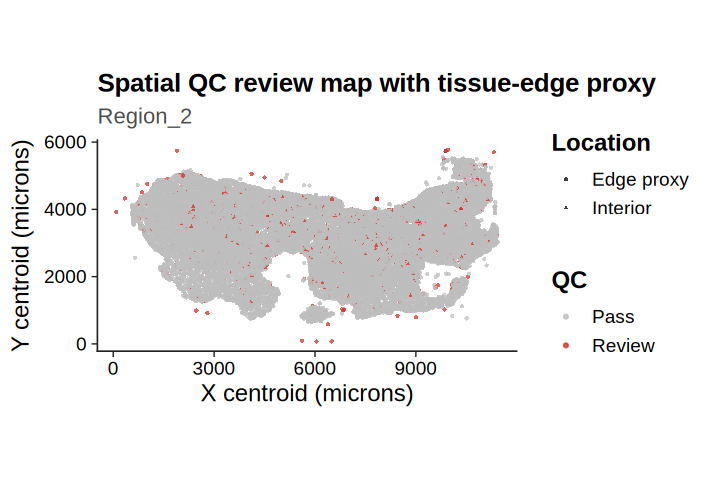

In [94]:
print(extended_plots$review_map)

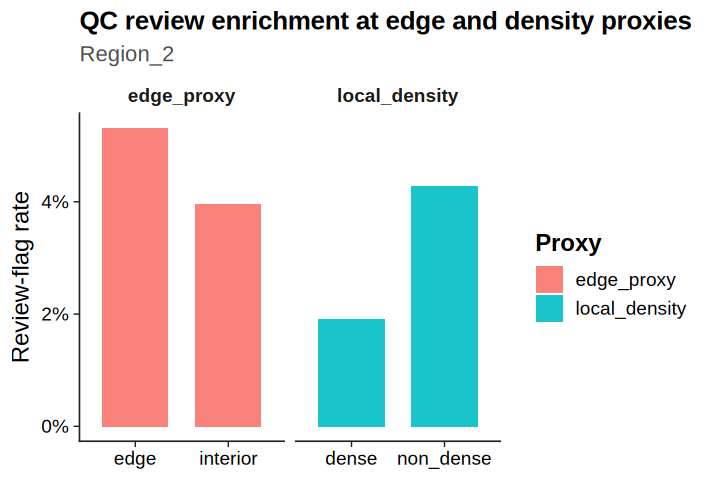

In [95]:
print(extended_plots$edge_density)

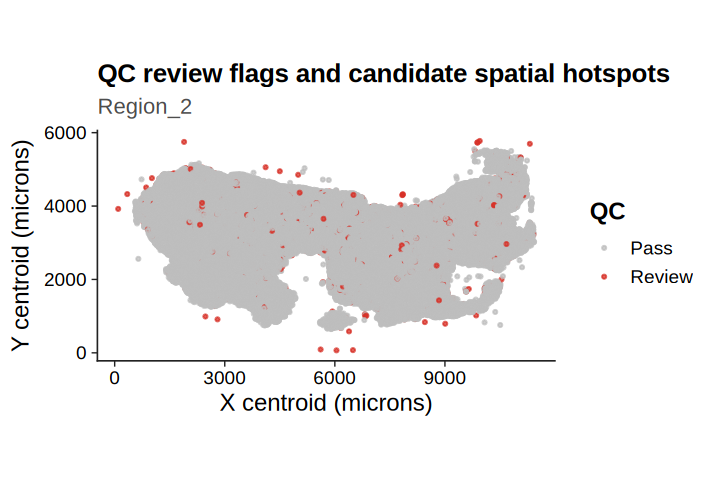

In [96]:
# there is no identified hotspots
print(extended_plots$hotspots)

## Step7 - Evidence-only downstream masks

### Downstream masks (raw objects remain unchanged)

- `primary_include`: exactly `qc_core_pass`, using `5 < nFeature_Xenium < 200` and `10 < nCount_Xenium < 1000`.
- `strict_include`: `primary_include & !qc_review_flag`; this additionally removes cells carrying any nucleus, segmentation, area, control, or core-QC review flag.
- `hotspot_sensitivity_include`: `primary_include` with Region 3 morphology-review hotspot cells excluded.

The primary mask is the main downstream cohort. All flags and all raw cells remain stored for audit and sensitivity analyses.


In [97]:
mask_provenance <- paste(RUN_LABEL, REGION_ID, extended_mode, normalizePath(region_dir, winslash = "/", mustWork = TRUE), sep = "|")

In [98]:
mask_provenance

[1] "full_notebook_qc_v2|Region_2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_2__20260805__124712"

In [99]:
colnames(spatial_cells)

[1] "cell_id"                     "x_centroid"                 
 [3] "y_centroid"                  "transcript_counts"          
 [5] "control_probe_counts"        "genomic_control_counts"     
 [7] "control_codeword_counts"     "unassigned_codeword_counts" 
 [9] "deprecated_codeword_counts"  "total_counts"               
[11] "cell_area"                   "nucleus_area"               
[13] "nucleus_count"               "segmentation_method"        
[15] "region_id"                   "nCount_Xenium"              
[17] "nFeature_Xenium"             "control_fraction_cell"      
[19] "nucleus_missing_flag"        "multiple_nuclei_flag"       
[21] "cell_area_outlier_flag"      "high_control_flag"          
[23] "segmentation_multiplet_flag" "qc_core_pass"               
[25] "qc_review_flag"              "mouse_id"                   
[27] "section_id"                  "biological_replicate_id"    
[29] "genotype"                    "treatment"                  
[31] "condition"                   "age_weeks"                  
[33] "metadata_status"             "do_not_interpret"           
[35] "grid_x"                      "grid_y"                     
[37] "grid_id"                     "edge_proxy"                 
[39] "grid_size_um"                "local_density"              
[41] "dense_aggregate"

In [100]:
downstream_masks <- build_cell_downstream_masks(spatial_cells, spatial_hotspots, mask_provenance)

In [101]:
colnames(downstream_masks)

[1] "cell_id"                       "x_centroid"                   
 [3] "y_centroid"                    "transcript_counts"            
 [5] "control_probe_counts"          "genomic_control_counts"       
 [7] "control_codeword_counts"       "unassigned_codeword_counts"   
 [9] "deprecated_codeword_counts"    "total_counts"                 
[11] "cell_area"                     "nucleus_area"                 
[13] "nucleus_count"                 "segmentation_method"          
[15] "region_id"                     "nCount_Xenium"                
[17] "nFeature_Xenium"               "control_fraction_cell"        
[19] "nucleus_missing_flag"          "multiple_nuclei_flag"         
[21] "cell_area_outlier_flag"        "high_control_flag"            
[23] "segmentation_multiplet_flag"   "qc_core_pass"                 
[25] "qc_review_flag"                "mouse_id"                     
[27] "section_id"                    "biological_replicate_id"      
[29] "genotype"                      "treatment"                    
[31] "condition"                     "age_weeks"                    
[33] "metadata_status"               "do_not_interpret"             
[35] "grid_x"                        "grid_y"                       
[37] "grid_id"                       "edge_proxy"                   
[39] "grid_size_um"                  "local_density"                
[41] "dense_aggregate"               "primary_include"              
[43] "strict_include"                "hotspot_review_cell"          
[45] "hotspot_sensitivity_include"   "section_status"               
[47] "mask_rule_primary"             "mask_rule_strict"             
[49] "mask_rule_hotspot_sensitivity" "provenance"

In [102]:
table(downstream_masks$primary_include)


FALSE  TRUE 
 1300 65680 

In [103]:
table(downstream_masks$strict_include)


FALSE  TRUE 
 2703 64277 

In [104]:
table(downstream_masks$hotspot_review_cell)


FALSE 
66980 

In [105]:
section_downstream_decision <- build_one_section_downstream_decision(
  downstream_masks, RUN_LABEL, extended_mode, mask_provenance,
  format(Sys.time(), tz = "UTC", usetz = TRUE)
)

In [106]:
section_downstream_decision

region_id,section_status,input_cells,primary_include_cells,primary_exclude_cells,strict_include_cells,strict_exclude_cells,hotspot_sensitivity_include_cells,hotspot_review_cells,cluster_discovery_eligible,⋯,region4_mapping_rule,primary_mask_rule,strict_mask_rule,hotspot_sensitivity_mask_rule,decision_rule,run_label,execution_mode,generated_utc,source_artifact,provenance
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Region_2,PRIMARY_CONDITIONAL,66980,65680,1300,64277,2703,65680,0,TRUE,⋯,NOT_APPLICABLE,qc_core_pass AND NOT segmentation_multiplet_flag AND NOT high_control_flag,NOT qc_review_flag,primary_include AND NOT Region_3 morphology-review hotspot cell,Fixed evidence-only section decision approved 2026-08-15; masks annotate without deleting raw cells,full_notebook_qc_v2,FULL_HPC,2026-08-18 07:53:02 UTC,section cell and spatial QC artifacts,full_notebook_qc_v2|Region_2|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_2__20260805__124712


In [107]:
with(downstream_masks, c(primary_include = sum(primary_include), strict_include = sum(strict_include), hotspot_sensitivity_include = sum(hotspot_sensitivity_include)))

primary_include              strict_include 
                      65680                       64277 
hotspot_sensitivity_include 
                      65680

## Step8 - Final Checks

In [108]:
# Main outputs
# Cell QC metadata saved as cell_qc_metadata.tsv.gz
# full qc rds: region_id+.phase0_2_qc.rds
# sessionInfo: sessionInfo.txt
artifact_paths <- write_section_artifacts(
  project_root = PROJECT_ROOT, output_dir = SECTION_OUTPUT_DIR, region_id = REGION_ID,
  configuration = configuration, manifest = section_manifest, environment = environment,
  inventory = inventory, integrity = integrity, feature_type_summary = feature_type_summary,
  panel_reconciliation = panel_reconciliation, alarms = alarms, qc = qc,
  counts = xenium$counts, features = xenium$features, strict_mode = STRICT_MODE
)

In [109]:
stopifnot(validate_section_artifacts(SECTION_OUTPUT_DIR, REGION_ID))

In [110]:
readiness <- utils::read.delim(file.path(SECTION_OUTPUT_DIR, "section_readiness_gates.tsv"), check.names = FALSE)
readiness

gate,status,details
<chr>,<chr>,<chr>
required_files,PASS,0 missing required files
matrix_integrity,PASS,"Matrix, features, barcodes, and cells must align"
panel_reconciliation,PASS,0 missing/extra expected-panel entries
metadata,PASS,Synthetic metadata blocks biological interpretation
xenium_analysis_alerts,HOLD,1 alarms; 1 errors
overall,HOLD,Worst-case readiness across gates


In [111]:
# Cell metatable: spatial_qc_cell_annotations.tsv.gz
extended_artifact_paths <- write_extended_section_artifacts(
  project_root = PROJECT_ROOT, output_dir = SECTION_OUTPUT_DIR, region_id = REGION_ID, mode = extended_mode,
  preflight = extended_preflight, cycle_alarm_evidence = cycle_alarm_evidence, gene_quality = gene_quality,
  spatial_global = spatial_global, spatial_edge_density = spatial_edge_density, spatial_hotspots = spatial_hotspots,
  spatial_cells = spatial_cells, manual_review_manifest = manual_review_manifest, plots = extended_plots
)

In [112]:
stopifnot(validate_extended_section_artifacts(SECTION_OUTPUT_DIR, REGION_ID, extended_mode))

In [113]:
extended_reload <- read_extended_section_artifacts(SECTION_OUTPUT_DIR, REGION_ID, extended_mode)
stopifnot(nrow(extended_reload$spatial_cells) == nrow(qc$cell_metadata))

In [114]:
extended_reload$status

region_id,mode,transcript_status,diagnostic_status,cells,cells_deleted,cycle_identity_status,morphology_status
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
Region_2,FULL_HPC,COMPUTED,FULL_HPC_COMPLETE,66980,0,CYCLE_IDENTITY_UNRESOLVED_REQUIRES_10X,COORDINATE_DIAGNOSTICS_REQUIRE_IMAGE_REVIEW


In [115]:
section_mask_path <- write_gz_tsv(downstream_masks, file.path(SECTION_OUTPUT_DIR, "cell_downstream_masks.tsv.gz"), PROJECT_ROOT)
section_decision_path <- write_tsv(section_downstream_decision, file.path(SECTION_OUTPUT_DIR, "section_downstream_decision.tsv"), PROJECT_ROOT)
stopifnot(file.exists(section_mask_path), file.exists(section_decision_path))

## Outputs

All outputs are section-specific. The section notebook creates `cell_downstream_masks.tsv.gz` and `section_downstream_decision.tsv`

In [116]:
data.frame(artifact = basename(artifact_paths), path = artifact_paths)[seq_len(min(length(artifact_paths), 20L)), , drop = FALSE]
data.frame(artifact = basename(extended_artifact_paths), path = extended_artifact_paths)
cat("Completed", REGION_ID, "with", nrow(qc$cell_metadata), "cells; zero cells deleted. Extended mode:", extended_mode, "\n")

,artifact,path
,<chr>,<chr>
1,configuration.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/configuration.tsv
2,section_manifest.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/section_manifest.tsv
3,environment_preflight.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/environment_preflight.tsv
4,file_inventory.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/file_inventory.tsv
5,integrity_summary.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/integrity_summary.tsv
6,feature_type_summary.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/feature_type_summary.tsv
7,panel_reconciliation.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/panel_reconciliation.tsv
8,analysis_alerts.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/analysis_alerts.tsv
9,qc_thresholds.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/qc_thresholds.tsv


artifact,path
<chr>,<chr>
extended_qc_preflight.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/extended_qc_preflight.tsv
cycle_alarm_evidence.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/cycle_alarm_evidence.tsv
gene_transcript_quality.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/gene_transcript_quality.tsv
spatial_qc_global.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/spatial_qc_global.tsv
spatial_qc_edge_density.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/spatial_qc_edge_density.tsv
spatial_qc_hotspots.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/spatial_qc_hotspots.tsv
spatial_manual_review_manifest.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/spatial_manual_review_manifest.tsv
spatial_qc_cell_annotations.tsv.gz,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/spatial_qc_cell_annotations.tsv.gz
extended_qc_status.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_2/extended_qc_status.tsv


Completed Region_2 with 66980 cells; zero cells deleted. Extended mode: FULL_HPC 
